In [27]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [28]:
# On crée notre dataframe en important le fichier csv.
used_device = pd.read_csv("used_device.csv", sep =',')

In [29]:
used_device.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [30]:
# On renomme les colonnes du dataframe.
used_device.columns = [
    "Marque",
    "Systeme",
    "Taille_ecran",
    "4G",
    "5G",
    "Resolution_cam_arriere",
    "Resolution_cam_avant",
    "Memoire_interne",
    "RAM",
    "Battery",
    "Poids",
    "Date_sortie",
    "Jours_utilisation",
    "Normalized_used_price",
    "Normalized_new_price"
]

In [31]:
used_device.head()

,Marque,Systeme,Taille_ecran,4G,5G,Resolution_cam_arriere,Resolution_cam_avant,Memoire_interne,RAM,Battery,Poids,Date_sortie,Jours_utilisation,Normalized_used_price,Normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [32]:
# On checke le type des différentes variables.
used_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Marque                  3454 non-null   object 
 1   Systeme                 3454 non-null   object 
 2   Taille_ecran            3454 non-null   float64
 3   4G                      3454 non-null   object 
 4   5G                      3454 non-null   object 
 5   Resolution_cam_arriere  3275 non-null   float64
 6   Resolution_cam_avant    3452 non-null   float64
 7   Memoire_interne         3450 non-null   float64
 8   RAM                     3450 non-null   float64
 9   Battery                 3448 non-null   float64
 10  Poids                   3447 non-null   float64
 11  Date_sortie             3454 non-null   int64  
 12  Jours_utilisation       3454 non-null   int64  
 13  Normalized_used_price   3454 non-null   float64
 14  Normalized_new_price    3454 non-null   

In [33]:
# Les colonnes 4G et 5G contient du texte (Yes/No). Nous devons donc transformer les données en chiffres (1/0) pour que le modèle fonctionne.
# Transformation des variables qualitatives en variables numériques
used_device = pd.get_dummies(used_device, columns=['4G'], drop_first=True,dtype=int)
used_device = pd.get_dummies(used_device, columns=['5G'], drop_first=True,dtype=int)

In [34]:
used_device.head()

,Marque,Systeme,Taille_ecran,Resolution_cam_arriere,Resolution_cam_avant,Memoire_interne,RAM,Battery,Poids,Date_sortie,Jours_utilisation,Normalized_used_price,Normalized_new_price,4G_yes,5G_yes
0,Honor,Android,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,1,0
1,Honor,Android,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,1,1
2,Honor,Android,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,1,1
3,Honor,Android,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,1,1
4,Honor,Android,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,1,0


### Corrélation entre les variables

In [36]:
# On cherche à voir le lien entre les différentes variables à travers une matrice de corrélation.
correlation_matrix = used_device.drop(columns=['Marque','Systeme']).corr()
correlation_matrix

,Taille_ecran,Resolution_cam_arriere,Resolution_cam_avant,Memoire_interne,RAM,Battery,Poids,Date_sortie,Jours_utilisation,Normalized_used_price,Normalized_new_price,4G_yes,5G_yes
Taille_ecran,1.000000,0.150316,0.271640,0.071291,0.274449,0.813533,0.828890,0.364223,-0.291723,0.614785,0.460889,0.259424,0.166163
Resolution_cam_arriere,0.150316,1.000000,0.429264,0.018766,0.260802,0.248563,-0.087738,0.353728,-0.144672,0.587302,0.541655,0.556271,0.026118
Resolution_cam_avant,0.271640,0.429264,1.000000,0.296426,0.477411,0.369709,-0.004997,0.690942,-0.552636,0.608074,0.475479,0.488272,0.389946
Memoire_interne,0.071291,0.018766,0.296426,1.000000,0.122496,0.117736,0.014948,0.235429,-0.242712,0.190993,0.195992,0.069799,0.261080
RAM,0.274449,0.260802,0.477411,0.122496,1.000000,0.280740,0.089916,0.314203,-0.280066,0.520289,0.532056,0.253279,0.571728
Battery,0.813533,0.248563,0.369709,0.117736,0.280740,1.000000,0.703388,0.488660,-0.370895,0.613619,0.470754,0.394779,0.204511
Poids,0.828890,-0.087738,-0.004997,0.014948,0.089916,0.703388,1.000000,0.071290,-0.067470,0.382354,0.269540,0.011274,0.060994
Date_sortie,0.364223,0.353728,0.690942,0.235429,0.314203,0.488660,0.071290,1.000000,-0.750390,0.509790,0.303689,0.612454,0.354571
Jours_utilisation,-0.291723,-0.144672,-0.552636,-0.242712,-0.280066,-0.370895,-0.067470,-0.750390,1.000000,-0.358264,-0.216625,-0.358217,-0.363333
Normalized_used_price,0.614785,0.587302,0.608074,0.190993,0.520289,0.613619,0.382354,0.509790,-0.358264,1.000000,0.834496,0.550657,0.313640


In [37]:
# On vérifie que le changement a bien été effectué.
used_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Marque                  3454 non-null   object 
 1   Systeme                 3454 non-null   object 
 2   Taille_ecran            3454 non-null   float64
 3   Resolution_cam_arriere  3275 non-null   float64
 4   Resolution_cam_avant    3452 non-null   float64
 5   Memoire_interne         3450 non-null   float64
 6   RAM                     3450 non-null   float64
 7   Battery                 3448 non-null   float64
 8   Poids                   3447 non-null   float64
 9   Date_sortie             3454 non-null   int64  
 10  Jours_utilisation       3454 non-null   int64  
 11  Normalized_used_price   3454 non-null   float64
 12  Normalized_new_price    3454 non-null   float64
 13  4G_yes                  3454 non-null   int32  
 14  5G_yes                  3454 non-null   

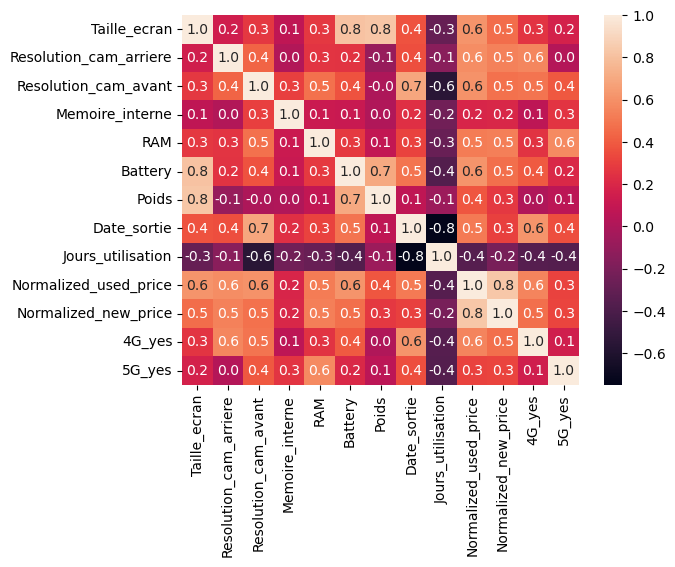

In [38]:
# On créé une matrice de corrélation
sns.heatmap(correlation_matrix, annot=True, fmt=".1f")
plt.show()

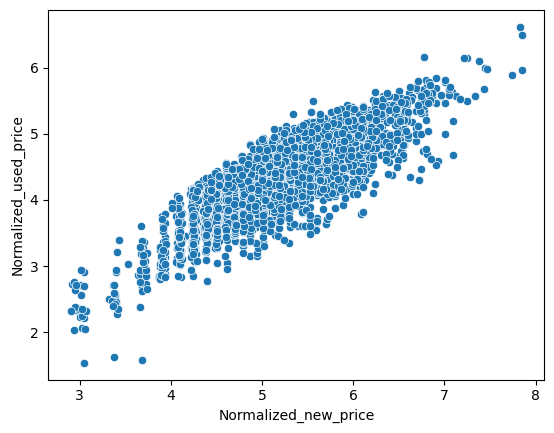

In [39]:
# On cherche à voir la corrélation entre les variables Normalized_new_price et Normalized_used_price (cible), à l'aide d'un nuage de points.
sns.scatterplot(data=used_device, x='Normalized_new_price', y='Normalized_used_price')
plt.show()

On peut voir qu'il y a une forte relation positive entre le prix d'un appareil neuf du même modèle et le prix d'occasion. La valeur de revente suit le positionnement du prix d'origine.

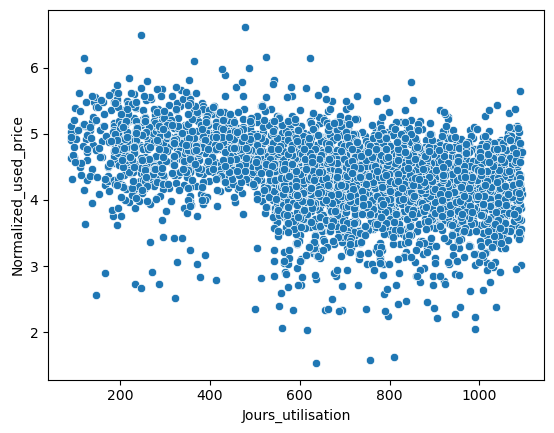

In [41]:
# On cherche à voir la corrélation entre les variables Jours_utilisation et Normalized_used_price (cible), à l'aide d'un nuage de points.
sns.scatterplot(data=used_device, x='Jours_utilisation', y='Normalized_used_price')
plt.show()

On peut voir qu'il y a une relation faible entre ces deux variables puisque les points sont très dispersés. Le nombre de jours d'utilisation de l'appareil n'explique donc qu'une infime partie de la variation du prix d'occasion. D'autres facteurs ont plus d'impact.

### Nettoyage des données

In [44]:
# On vérifie s'il n'y a pas de valeurs manquantes.
used_device.isnull().sum()

Marque                      0
Systeme                     0
Taille_ecran                0
Resolution_cam_arriere    179
Resolution_cam_avant        2
Memoire_interne             4
RAM                         4
Battery                     6
Poids                       7
Date_sortie                 0
Jours_utilisation           0
Normalized_used_price       0
Normalized_new_price        0
4G_yes                      0
5G_yes                      0
dtype: int64

In [45]:
# On remplace les valeurs manquantes par la médiane pour chaque colonne contenant des valeurs manquantes (sauf Resolution_cam_arriere, pour laquelle on va les supprimer).
used_device.fillna({'Resolution_cam_avant': used_device['Resolution_cam_avant'].median()}, inplace=True)
used_device.fillna({'Memoire_interne': used_device['Memoire_interne'].median()}, inplace=True)
used_device.fillna({'RAM': used_device['RAM'].median()}, inplace=True)
used_device.fillna({'Battery': used_device['Battery'].median()}, inplace=True)
used_device.fillna({'Poids': used_device['Poids'].median()}, inplace=True)
used_device.isnull().sum()

Marque                      0
Systeme                     0
Taille_ecran                0
Resolution_cam_arriere    179
Resolution_cam_avant        0
Memoire_interne             0
RAM                         0
Battery                     0
Poids                       0
Date_sortie                 0
Jours_utilisation           0
Normalized_used_price       0
Normalized_new_price        0
4G_yes                      0
5G_yes                      0
dtype: int64

In [46]:
# On supprime les valeurs manquantes dans la colonne Resolution_cam_arriere car il y en beaucoup trop, ce qui peut impacter d'autres lignes. Nous ne prendrons pas en compte cette colonne comme variable explicative.
used_device = used_device.drop(columns=['Resolution_cam_arriere'])
used_device.isnull().sum()

Marque                   0
Systeme                  0
Taille_ecran             0
Resolution_cam_avant     0
Memoire_interne          0
RAM                      0
Battery                  0
Poids                    0
Date_sortie              0
Jours_utilisation        0
Normalized_used_price    0
Normalized_new_price     0
4G_yes                   0
5G_yes                   0
dtype: int64

### Création des dataframes (variable cible et variables explicatives) et modèles

#### Modèle 1

In [49]:
# On définit la variable cible y.
y = used_device["Normalized_used_price"]

# On définit les variables prédictives x.
x = used_device[["Taille_ecran","Resolution_cam_avant","RAM","Battery","Poids","Normalized_new_price", "Date_sortie", "Jours_utilisation","4G_yes","5G_yes"]]

In [50]:
# On crée les x_train, x_test, y_train, y_test pour pouvoir réaliser l'entraînement / le test.
# test_size=0.2 signifie 20% de données pour le test et 80% pour l'entraînement
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Taille de l'entraînement : {x_train.shape}")
print(f"Taille du test : {x_test.shape}")

Taille de l'entraînement : (2763, 10)
Taille du test : (691, 10)


In [51]:
# On affiche les résultats du modèle.
model = sm.OLS(y_train, x_train).fit()
results=model.summary()
print(results)

                                  OLS Regression Results                                  
Dep. Variable:     Normalized_used_price   R-squared (uncentered):                   0.997
Model:                               OLS   Adj. R-squared (uncentered):              0.997
Method:                    Least Squares   F-statistic:                          8.590e+04
Date:                   Sun, 01 Feb 2026   Prob (F-statistic):                        0.00
Time:                           10:40:21   Log-Likelihood:                         -76.756
No. Observations:                   2763   AIC:                                      173.5
Df Residuals:                       2753   BIC:                                      232.8
Df Model:                             10                                                  
Covariance Type:               nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-

- On remarque que les coefficients ne sont pas tous significatifs puisque certains p_value (P>|t|) sont supérieurs à 0,05.
- On voit que la variable Normalized_new_price est la plus influente. Quand le prix neuf normalisé augmente de 1, le prix d'occasion (variable cible) augmentera d'environ 0,47, toutes choses égales par ailleurs.
- On voit au contraire que la variable 5G a un effet d'influence plus modéré. Toutes choses égales par ailleurs, lorsqu'un appareil est compatible avec la 5G, le prix d'occasion diminuera environ de 0,10, par rapport à un appareil non compatible avec la 5G.

In [53]:
# On récupère les coefficients avec Linear Regression
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression().fit(x_train, y_train)
print(lin_model.coef_)

[ 3.53808170e-02  1.43116153e-02  2.60947303e-02 -4.69453883e-06
  2.63138932e-04  4.84871678e-01  3.18197584e-02  1.01207482e-04
  9.62868010e-02 -1.29296772e-01]


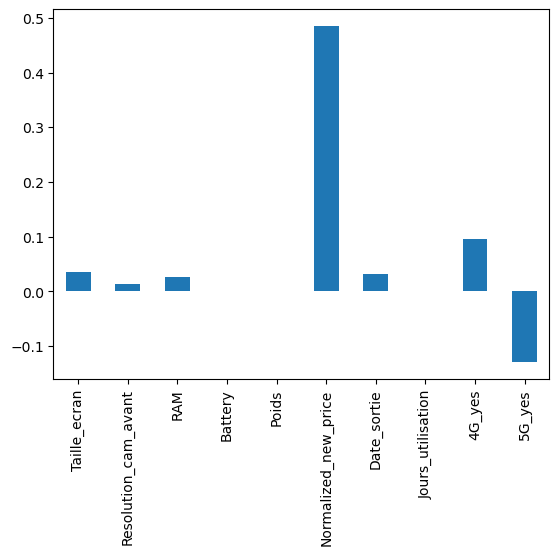

In [54]:
# On crée un graphique afin de visualiser ces coefficients.
coefficients = pd.Series(lin_model.coef_, index=x.columns)
coefficients.plot(kind='bar')
plt.show()

In [55]:
# On cherche à évaluer la fiabilité du modèle.
y_pred = lin_model.predict(x_test)
y_pred

array([3.96326976, 4.9105453 , 4.26083194, 4.11753758, 3.81780426,
       4.27435121, 4.59950185, 4.80271163, 4.07606333, 4.44214626,
       4.32608113, 4.47682129, 4.03338896, 4.46645917, 5.27832184,
       3.61862646, 4.31346074, 4.43456487, 4.24252812, 3.5462201 ,
       4.12586962, 4.3549754 , 3.60965815, 3.58606012, 4.45018665,
       4.90416346, 3.39280137, 4.19186712, 4.27136237, 4.88418571,
       4.34482472, 3.80461178, 5.76540635, 4.06693362, 3.56819974,
       5.23541877, 3.76264071, 4.81321326, 4.47818592, 4.9285445 ,
       4.90486667, 5.32384305, 4.34328804, 4.6468744 , 5.16888727,
       4.23951364, 4.69764758, 4.46339853, 3.94732889, 3.50012679,
       5.56314288, 4.98103247, 4.58864734, 3.94094429, 4.32099505,
       4.27390487, 4.40946698, 4.63745334, 5.26235563, 4.51574846,
       4.1845579 , 4.63924596, 4.10506985, 4.2423966 , 4.42051945,
       4.18154524, 3.66009834, 3.95390893, 4.34458921, 4.54459606,
       3.60713296, 4.71630682, 4.77740642, 3.42652423, 3.52250

In [56]:
# On analyse la performance avec MSE, RMSE, MAE et R².
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse=mean_squared_error(y_pred,y_test)**(1/2)
mae=mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 0.057071664911543106, RMSE: 0.2388967662224483, MAE: 0.19097365572528657, R²: 0.8241343199881974


Le coefficient de détermination (R²) obtenu sur l'échantillon test est de 0,8, ce qui témoigne d'un fort pouvoir explicatif du modèle. Cela indique que nous avons affaire à un modèle performant. En effet, le R² varie entre 0 et 1, où une valeur proche de 1 reflète une meilleure capacité à expliquer la variabilité des données.

Concernant les métriques d'erreur (MSE, RMSE et MAE), elles sont faibles, ce qui est également un bon indicateur de la qualité du modèle. Les prédictions de prix d’occasion normalisé s’écartent d’environ 0,19 à 0,24.

Toutefois, ces métriques seront particulièrement utiles pour comparer plusieurs modèles différents afin d’évaluer leurs performances respectives.

#### Modèle 2

In [59]:
# On définit la variable cible y_2.
y_2 = used_device["Normalized_used_price"]

# On définit les variables prédictives x_2.
x_2 = used_device[["Taille_ecran","RAM","Normalized_new_price", "Date_sortie","4G_yes","5G_yes"]]

In [60]:
# On crée les x2_train, x2_test, y2_train, y2_test pour pouvoir réaliser l'entraînement / le test.
# test_size=0.2 signifie 20% de données pour le test et 80% pour l'entraînement
x2_train, x2_test, y2_train, y2_test = train_test_split(x_2, y_2, test_size=0.2, random_state=42)

print(f"Taille de l'entraînement : {x2_train.shape}")
print(f"Taille du test : {x2_test.shape}")

Taille de l'entraînement : (2763, 6)
Taille du test : (691, 6)


In [61]:
# On affiche les résultats du modèle.
model_2 = sm.OLS(y2_train, x2_train).fit()
results=model_2.summary()
print(results)

                                  OLS Regression Results                                  
Dep. Variable:     Normalized_used_price   R-squared (uncentered):                   0.996
Model:                               OLS   Adj. R-squared (uncentered):              0.996
Method:                    Least Squares   F-statistic:                          1.258e+05
Date:                   Sun, 01 Feb 2026   Prob (F-statistic):                        0.00
Time:                           10:40:24   Log-Likelihood:                         -256.82
No. Observations:                   2763   AIC:                                      525.6
Df Residuals:                       2757   BIC:                                      561.2
Df Model:                              6                                                  
Covariance Type:               nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-

- On remarque que les coefficients ne sont pas tous significatifs puisque certains p_value (P>|t|) sont supérieurs à 0,05.
- Normalized_new_price est la variable avec le plus grand impact. Quand le prix neuf normalisé augmente de 1 unité, le prix d’occasion normalisé augmente d’environ 0,49 unité, toutes choses égales par ailleurs.
- La 5G n’a pas d’impact statistiquement significatif dans ce modèle et pourrait être retirée dans un modèle encore plus simple.

In [63]:
# On récupère les coefficients avec Linear Regression
lin_model_2 = LinearRegression().fit(x2_train, y2_train)
print(lin_model_2.coef_)

[ 0.03720072  0.03733989  0.52006722  0.0466667   0.09572547 -0.13137443]


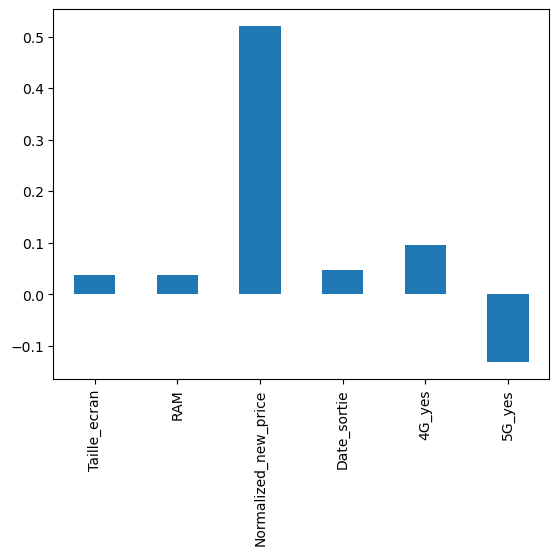

In [64]:
# On crée un graphique afin de visualiser ces coefficients.
coefficients_2 = pd.Series(lin_model_2.coef_, index=x_2.columns)
coefficients_2.plot(kind='bar')
plt.show()

In [65]:
# On cherche à évaluer la fiabilité du modèle.
y2_pred = lin_model_2.predict(x2_test)
y2_pred

array([3.96339794, 4.95723614, 4.25072419, 4.1240616 , 3.84432924,
       4.29773559, 4.65481994, 4.80051057, 4.10465833, 4.45168141,
       4.32874529, 4.55648429, 4.03151227, 4.5573189 , 5.21741209,
       3.64335419, 4.3089723 , 4.44350057, 4.25816974, 3.51251128,
       4.19658776, 4.33026415, 3.62390162, 3.60882932, 4.49388205,
       4.9429128 , 3.35425158, 4.18775   , 4.25403837, 4.94356665,
       4.36187857, 3.84511132, 5.65313944, 4.09979748, 3.56242807,
       5.04278474, 3.76505986, 4.79556483, 4.45644477, 4.76042269,
       4.95396658, 5.10242225, 4.36854148, 4.65545484, 5.15057954,
       4.2643835 , 4.63617742, 4.56206908, 3.94201622, 3.49530559,
       5.59371587, 4.95624111, 4.65212909, 3.92123804, 4.37917966,
       4.26549208, 4.42268766, 4.64192828, 5.4593892 , 4.50162408,
       4.23421609, 4.56068016, 4.1674382 , 4.30382938, 4.43933834,
       4.1751269 , 3.68025499, 3.9406419 , 4.39135066, 4.60787766,
       3.59121271, 4.7050708 , 4.67817044, 3.42413486, 3.52006

In [66]:
# On analyse la performance avec MSE, RMSE, MAE et R².
mse = mean_squared_error(y2_test, y2_pred)
rmse=mean_squared_error(y2_pred,y2_test)**(1/2)
mae=mean_absolute_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)
print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 0.06430336360899983, RMSE: 0.253581078964894, MAE: 0.20193832755040225, R²: 0.8018499235010808


Comme le modèle 1, le coefficient de détermination (R²) obtenu sur l'échantillon test est de 0,8, ce qui témoigne d'un fort pouvoir explicatif du modèle. Cela indique que nous avons affaire à un modèle performant. En effet, le R² varie entre 0 et 1, où une valeur proche de 1 reflète une meilleure capacité à expliquer la variabilité des données.

Concernant les métriques d'erreur (MSE, RMSE et MAE), elles sont faibles, ce qui est également un bon indicateur de la qualité du modèle. Les prédictions de prix d’occasion normalisé s’écartent en moyenne d’environ 0,20 à 0,25 de la valeur réelle (selon que l'on observe la MAE ou la RMSE).

#### Comparaison des deux modèles

D'après les résultats obtenus, le Modèle 1 est donc le plus performant des deux. En effet, il présente un coefficient de détermination (R²) plus élevé (0,82 contre 0,80), ce qui signifie qu'il explique une plus grande part de la variabilité des prix, tout en affichant des erreurs (MAE et RMSE) plus faibles.

#### Bonus : Modèle 3

In [71]:
# On définit la variable cible y_3.
y_3 = used_device["Normalized_used_price"]

# On définit les variables prédictives x_3.
x_3 = used_device[["Taille_ecran","RAM","Normalized_new_price", "Date_sortie","4G_yes"]]

In [72]:
# On crée les x3_train, x3_test, y3_train, y3_test pour pouvoir réaliser l'entraînement / le test.
# test_size=0.2 signifie 20% de données pour le test et 80% pour l'entraînement
x3_train, x3_test, y3_train, y3_test = train_test_split(x_3, y_3, test_size=0.2, random_state=42)

print(f"Taille de l'entraînement : {x3_train.shape}")
print(f"Taille du test : {x3_test.shape}")

Taille de l'entraînement : (2763, 5)
Taille du test : (691, 5)


In [73]:
# On affiche les résultats du modèle.
model_3 = sm.OLS(y3_train, x3_train).fit()
results=model_3.summary()
print(results)

                                  OLS Regression Results                                  
Dep. Variable:     Normalized_used_price   R-squared (uncentered):                   0.996
Model:                               OLS   Adj. R-squared (uncentered):              0.996
Method:                    Least Squares   F-statistic:                          1.510e+05
Date:                   Sun, 01 Feb 2026   Prob (F-statistic):                        0.00
Time:                           10:40:25   Log-Likelihood:                         -256.83
No. Observations:                   2763   AIC:                                      523.7
Df Residuals:                       2758   BIC:                                      553.3
Df Model:                              5                                                  
Covariance Type:               nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-

In [74]:
# On récupère les coefficients avec Linear Regression
lin_model_3 = LinearRegression().fit(x3_train, y3_train)
print(lin_model_3.coef_)

[0.03771862 0.02771366 0.516612   0.04303121 0.10654453]


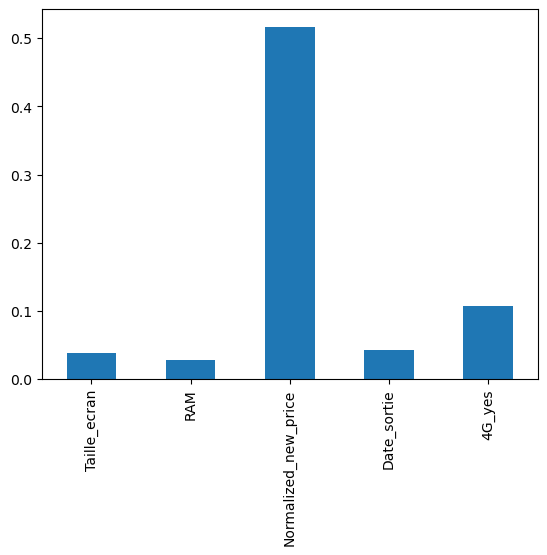

In [75]:
# On crée un graphique afin de visualiser ces coefficients.
coefficients_3 = pd.Series(lin_model_3.coef_, index=x_3.columns)
coefficients_3.plot(kind='bar')
plt.show()

In [76]:
# On cherche à évaluer la fiabilité du modèle.
y3_pred = lin_model_3.predict(x3_test)
y3_pred

array([3.95948036, 4.94688874, 4.2491408 , 4.12572748, 3.84208508,
       4.2991653 , 4.65387727, 4.89696188, 4.10262784, 4.44886235,
       4.3301067 , 4.54816185, 4.03286693, 4.56830826, 5.2013502 ,
       3.63905863, 4.30700192, 4.43734923, 4.25321144, 3.51435369,
       4.20611022, 4.32492633, 3.61973529, 3.60281988, 4.48417   ,
       5.01846058, 3.38698362, 4.19333533, 4.24430335, 4.93267252,
       4.35475253, 3.83624934, 5.68649427, 4.10402391, 3.55876961,
       5.1363488 , 3.76485933, 4.79138719, 4.4601455 , 4.7474964 ,
       4.95255635, 5.18099313, 4.36627479, 4.66033767, 5.2443149 ,
       4.25619619, 4.62468097, 4.57302689, 3.9491347 , 3.49347528,
       5.58970016, 4.92432862, 4.65455269, 3.91852117, 4.37345858,
       4.26713601, 4.42671212, 4.64025009, 5.40098107, 4.49763204,
       4.24077545, 4.56040118, 4.16062942, 4.297089  , 4.44315272,
       4.16743313, 3.67238883, 3.93631446, 4.3988093 , 4.60073369,
       3.590589  , 4.70721917, 4.6705212 , 3.4227774 , 3.51991

In [77]:
# On analyse la performance avec MSE, RMSE, MAE et R².
mse = mean_squared_error(y3_test, y3_pred)
rmse=mean_squared_error(y3_pred,y3_test)**(1/2)
mae=mean_absolute_error(y3_test, y3_pred)
r2 = r2_score(y3_test, y3_pred)
print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 0.06430979200995542, RMSE: 0.25359375388592564, MAE: 0.2012870363606739, R²: 0.8018301144573601


Comme les 2 autres modèles, le coefficient de détermination (R²) obtenu sur l'échantillon test est de 0,8, ce qui témoigne d'un fort pouvoir explicatif du modèle. Cela indique que nous avons affaire à un modèle performant. En effet, le R² varie entre 0 et 1, où une valeur proche de 1 reflète une meilleure capacité à expliquer la variabilité des données.

Concernant les métriques d'erreur (MSE, RMSE et MAE), elles sont faibles, ce qui est également un bon indicateur de la qualité du modèle. Les prédictions de prix d’occasion normalisé s’écartent en moyenne d’environ 0,20 à 0,25 de la valeur réelle (selon que l'on observe la MAE ou la RMSE).

### Comparaison des trois modèles

D'après les résultats obtenus, le Modèle 1 est donc le plus performant des trois. En effet, il présente un coefficient de détermination (R²) plus élevé (0,82 contre 0,80), ce qui signifie qu'il explique une plus grande part de la variabilité des prix, tout en affichant des erreurs (MAE et RMSE) plus faibles.

On privilégiera donc ce modèle car il offre une meilleure précision globale et des prédictions plus proches des valeurs réelles.